# Влияние параметра eta

В этом ноутбуке исследуется влияние параметра `eta` на развитие электрического пробоя.

Параметр `eta` управляет тем, насколько сильно рост канала предпочитает клетки с большим локальным drive. Чем больше `eta`, тем более направленным становится стохастический рост.

Для каждого значения `eta` используются одинаковые наборы `disorder_seed` и `random_seed`, чтобы сравнение между режимами было корректным.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import SimulationConfig
from src.analysis_utils import (
    run_parameter_sweep,
    build_material_summary,
    build_bootstrap_summary,
)

In [2]:
base_config = SimulationConfig(
    nx=128,
    ny=128,
    correlation_length=5.0,
    weibull_shape=5.0,
    mean_breakdown_field=3.0,
    max_growth_steps=5000,
)

In [3]:
eta_values = [0.5, 1.0, 1.5, 2.0, 3.0]

disorder_seeds = range(20)
random_seeds = range(10)

total_runs = (
    len(eta_values)
    * len(disorder_seeds)
    * len(random_seeds)
)

print("Total simulations:", total_runs)

Total simulations: 1000


## Основной sweep

Для каждого значения `eta` запускаются 20 различных реализаций материала. Для каждой реализации материала рассматриваются 10 стохастических траекторий роста.

Итого:

$$
5 \times 20 \times 10 = 1000
$$

симуляций.

In [4]:
results_df = run_parameter_sweep(
    base_config=base_config,
    parameter_name="eta",
    parameter_values=eta_values,
    disorder_seeds=disorder_seeds,
    random_seeds=random_seeds,
)

In [5]:
print(results_df.shape)

print(
    results_df.groupby("eta").size()
)

results_df.to_csv(
    "eta_results.csv",
    index=False,
)

(1000, 9)
eta
0.5    200
1.0    200
1.5    200
2.0    200
3.0    200
dtype: int64


## Агрегация на уровне материала

Одна строка `material_summary` соответствует одной реализации материала (`disorder_seed`) при фиксированном `eta`.

Десять разных `random_seed` внутри одного материала используются для оценки вероятностей старта и полного пробоя.

In [6]:
material_summary = build_material_summary(
    results_df,
    parameter_name="eta",
)

material_summary.head()

,eta,disorder_seed,n_started,n_breakdown,p_start,p_breakdown,mean_steps,mean_height,p_breakdown_given_start
0,0.5,0,10,10,1.0,1.0,771.4,1.000000,1.0
1,0.5,1,0,0,0.0,0.0,0.0,0.000000,NaN
2,0.5,2,10,10,1.0,1.0,868.2,1.000000,1.0
3,0.5,3,0,0,0.0,0.0,0.0,0.000000,NaN
4,0.5,4,10,0,1.0,0.0,3.0,0.125984,0.0


In [7]:
stats = build_bootstrap_summary(
    material_summary,
    parameter_name="eta",
    parameter_values=eta_values,
    n_random=len(random_seeds),
)

stats

,p_start,p_start_low,p_start_high,p_breakdown,p_breakdown_low,p_breakdown_high,p_breakdown_given_start,conditional_low,conditional_high,eta
0,0.60130,0.4,0.8,0.55090,0.35,0.75,0.916289,0.727273,1.0,0.5
1,0.59770,0.4,0.8,0.54723,0.35,0.75,0.915774,0.727273,1.0,1.0
2,0.59659,0.4,0.8,0.54631,0.30,0.75,0.915724,0.727273,1.0,1.5
3,0.59704,0.4,0.8,0.54795,0.35,0.75,0.917873,0.727273,1.0,2.0
4,0.60047,0.4,0.8,0.55001,0.35,0.75,0.916045,0.727273,1.0,3.0


## Вероятность старта

Исследуем зависимость

$$
P(start \mid \eta).
$$

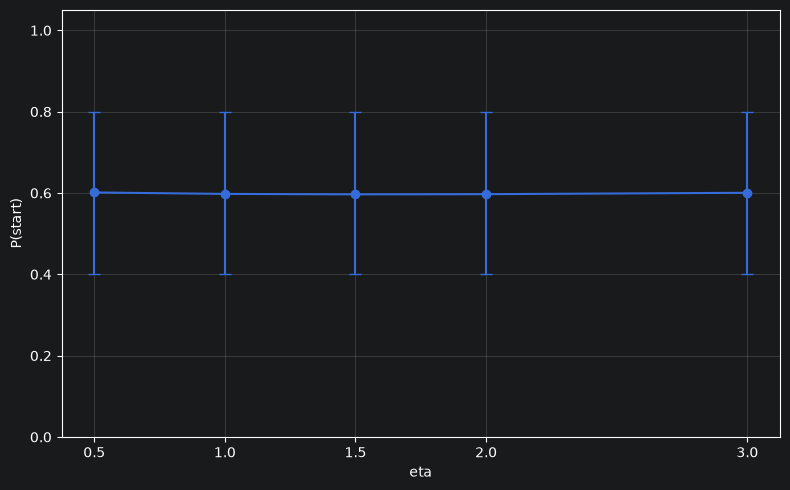

In [8]:
plt.figure(figsize=(8, 5))

yerr = np.vstack([
    stats["p_start"] - stats["p_start_low"],
    stats["p_start_high"] - stats["p_start"],
])

plt.errorbar(
    stats["eta"],
    stats["p_start"],
    yerr=yerr,
    marker="o",
    capsize=4,
)

plt.xlabel("eta")
plt.ylabel("P(start)")
plt.xticks(eta_values)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Вывод

Во всём исследованном диапазоне параметра `eta`

$$
P(start) = 0.60.
$$

Вероятность старта полностью совпадает для всех значений `eta`.

Это ожидаемо из структуры модели: параметр `eta` входит в вероятности выбора следующей клетки

$$
P_i \propto d_i^\eta,
$$

но не входит в условие существования активной клетки

$$
d_i > 0.
$$

Следовательно, `eta` не должен влиять непосредственно на возможность начального старта канала. Полученный численный результат согласуется с этим свойством модели.

## Общая вероятность полного пробоя

Исследуем зависимость

$$
P(breakdown \mid \eta).
$$

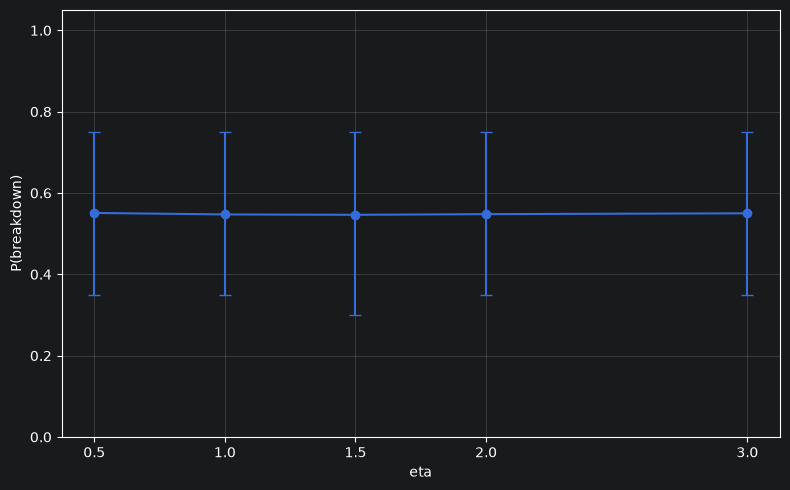

In [9]:
plt.figure(figsize=(8, 5))

yerr = np.vstack([
    stats["p_breakdown"] - stats["p_breakdown_low"],
    stats["p_breakdown_high"] - stats["p_breakdown"],
])

plt.errorbar(
    stats["eta"],
    stats["p_breakdown"],
    yerr=yerr,
    marker="o",
    capsize=4,
)

plt.xlabel("eta")
plt.ylabel("P(breakdown)")
plt.xticks(eta_values)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Вывод

Общая вероятность полного пробоя также практически не зависит от `eta`:

$$
P(breakdown) = 0.55
$$

для всех исследованных значений параметра.

Более того, для каждой пары

$$
(disorder\_seed,\ random\_seed)
$$

итоговый статус симуляции совпадает при всех значениях `eta`.

Таким образом, в данном диапазоне параметров `eta` не меняет класс исхода процесса (`no_start`, `arrested`, `breakdown`), хотя может существенно менять саму траекторию роста.

## Вероятность полного пробоя после старта

Отдельно исследуем дальнейшее распространение уже возникшего канала:

$$
P(breakdown \mid start, \eta).
$$

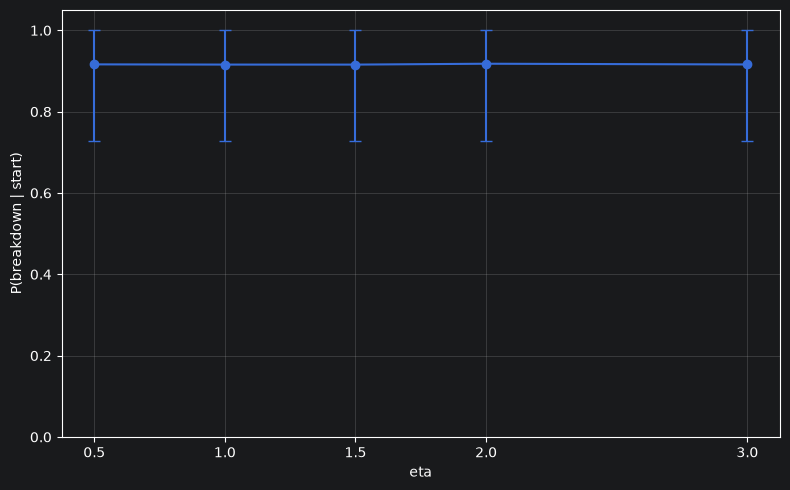

In [10]:
plt.figure(figsize=(8, 5))

yerr = np.vstack([
    stats["p_breakdown_given_start"] - stats["conditional_low"],
    stats["conditional_high"] - stats["p_breakdown_given_start"],
])

plt.errorbar(
    stats["eta"],
    stats["p_breakdown_given_start"],
    yerr=yerr,
    marker="o",
    capsize=4,
)

plt.xlabel("eta")
plt.ylabel("P(breakdown | start)")
plt.xticks(eta_values)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Вывод

Условная вероятность полного пробоя после старта также остаётся постоянной:

$$
P(breakdown \mid start) \approx 0.917.
$$

То есть среди 120 стартовавших траекторий 110 завершаются полным пробоем независимо от значения `eta`.

В рассматриваемом режиме параметр `eta` практически не определяет, дойдёт ли уже стартовавший канал до противоположного электрода. Его влияние следует искать прежде всего в динамике и морфологии роста.

## Дополнительные характеристики роста

Для `eta` особенно важно посмотреть не только исход симуляции, но и характеристики траектории: число шагов и достигнутую относительную высоту.

In [17]:
started_df = results_df[
    results_df["started"]
].copy()

growth_summary = (
    started_df
    .groupby("eta")
    .agg(
        n=("steps", "size"),
        mean_steps=("steps", "mean"),
        median_steps=("steps", "median"),
        std_steps=("steps", "std"),
        q25_steps=("steps", lambda x: x.quantile(0.25)),
        q75_steps=("steps", lambda x: x.quantile(0.75)),
        mean_height=("height_fraction", "mean"),
    )
)

growth_summary

,n,mean_steps,median_steps,std_steps,q25_steps,q75_steps,mean_height
eta,,,,,,,
0.5,120,741.641667,801.0,264.032364,672.00,899.00,0.927165
1.0,120,432.441667,470.0,153.641392,391.00,512.25,0.927165
1.5,120,317.275000,346.0,106.649978,294.00,372.00,0.927165
2.0,120,264.491667,281.0,86.842463,251.75,308.25,0.927165
3.0,120,205.550000,220.5,64.507813,204.75,236.25,0.927165


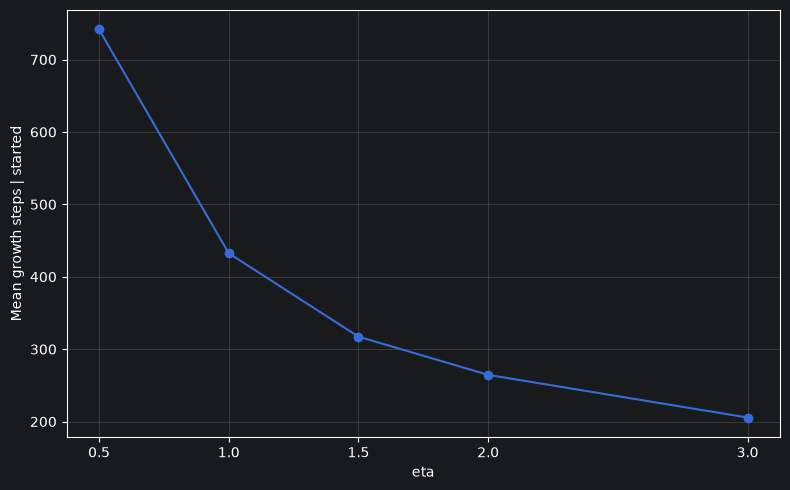

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    growth_summary.index,
    growth_summary["mean_steps"],
    marker="o",
)

plt.xlabel("eta")
plt.ylabel("Mean growth steps | started")
plt.xticks(eta_values)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Вывод по числу шагов

В отличие от вероятностей исхода, число шагов роста сильно зависит от `eta`.

Среднее число шагов среди стартовавших траекторий уменьшается примерно от

$$
742
$$

при

$$
\eta = 0.5
$$

до

$$
206
$$

при

$$
\eta = 3.
$$

Таким образом, увеличение `eta` делает рост существенно более направленным.

При малом `eta` вероятности выбора различных активных клеток ближе друг к другу, поэтому канал сильнее блуждает и формирует более длинную траекторию.

При большом `eta` преимущество клеток с большим локальным drive усиливается:

$$
P_i \propto d_i^\eta,
$$

поэтому канал чаще выбирает наиболее благоприятное направление и достигает своего конечного состояния за меньшее число шагов.

Следовательно, `eta` является в первую очередь параметром кинетики и морфологии роста, а не параметром вероятности старта.

## Статистическая проверка влияния eta на вероятность старта

In [19]:
pivot_start = material_summary.pivot(
    index="disorder_seed",
    columns="eta",
    values="p_start",
)

all_equal = (
    pivot_start.nunique(axis=1) == 1
).all()

print(
    "P(start) identical for all eta:",
    all_equal,
)

P(start) identical for all eta: True


Дисперсия между условиями равна нулю.

Это не отсутствие статистической мощности, а более сильный результат:
в рассматриваемом эксперименте изменение `eta` вообще не изменило факт старта ни для одной реализации материала.

In [28]:
material_steps = (
    started_df
    .groupby(["eta", "disorder_seed"])
    .agg(
        mean_steps_started=("steps", "mean"),
    )
    .reset_index()
)

pivot_steps = material_steps.pivot(
    index="disorder_seed",
    columns="eta",
    values="mean_steps_started",
).dropna()

pivot_steps

eta,0.5,1.0,1.5,2.0,3.0
disorder_seed,,,,,
0,771.4,433.1,356.8,290.0,220.9
2,868.2,519.9,357.4,306.2,228.0
4,3.0,3.0,3.0,3.0,3.0
5,804.9,436.2,335.6,280.3,209.6
6,795.0,487.2,357.1,284.6,226.7
7,763.5,485.4,336.4,290.3,221.6
8,788.7,453.3,320.1,275.9,217.0
10,798.6,461.7,343.8,284.0,222.1
11,750.4,433.2,310.7,259.2,207.2


In [29]:
from scipy.stats import friedmanchisquare

stat, p_value = friedmanchisquare(
    *[
        pivot_steps[eta].values
        for eta in eta_values
    ]
)

kendall_w = (
    stat /
    (
        len(pivot_steps)
        * (len(eta_values) - 1)
    )
)

print("Friedman statistic:", stat)
print("p-value:", p_value)
print("Kendall W:", kendall_w)

Friedman statistic: 43.99999999999998
p-value: 6.4157766135985905e-09
Kendall W: 0.9166666666666662


### Статистическая проверка влияния eta на число шагов

Для сравнения числа шагов использовался связанный дизайн:
одни и те же `disorder_seed` сравнивались при всех значениях `eta`.

Критерий Фридмана дал

$$
\chi_F^2 \approx 44.0,
$$

$$
p \approx 6.4 \times 10^{-9}.
$$

Размер эффекта по Kendall's W:

$$
W \approx 0.92.
$$

Следовательно, влияние `eta` на число шагов роста является статистически значимым и очень сильным.

In [30]:
from itertools import combinations
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

pairwise_results = []

for eta1, eta2 in combinations(
    eta_values,
    2,
):
    x = pivot_steps[eta1].values
    y = pivot_steps[eta2].values

    if np.allclose(x, y):
        stat = 0.0
        p_value = 1.0
    else:
        stat, p_value = wilcoxon(
            x,
            y,
        )

    pairwise_results.append(
        {
            "eta1": eta1,
            "eta2": eta2,
            "mean_diff_steps": np.mean(x - y),
            "p_value": p_value,
        }
    )

pairwise_steps = pd.DataFrame(
    pairwise_results
)

pairwise_steps["p_adjusted"] = (
    multipletests(
        pairwise_steps["p_value"],
        method="holm",
    )[1]
)

pairwise_steps["significant"] = (
    pairwise_steps["p_adjusted"] < 0.05
)

pairwise_steps

,eta1,eta2,mean_diff_steps,p_value,p_adjusted,significant
0,0.5,1.0,309.200000,0.000977,0.009766,True
1,0.5,1.5,424.366667,0.000977,0.009766,True
2,0.5,2.0,477.150000,0.000977,0.009766,True
3,0.5,3.0,536.091667,0.000977,0.009766,True
4,1.0,1.5,115.166667,0.000977,0.009766,True
5,1.0,2.0,167.950000,0.000977,0.009766,True
6,1.0,3.0,226.891667,0.000977,0.009766,True
7,1.5,2.0,52.783333,0.000977,0.009766,True
8,1.5,3.0,111.725000,0.000977,0.009766,True
9,2.0,3.0,58.941667,0.000977,0.009766,True


### Post-hoc анализ

Парные сравнения Wilcoxon с поправкой Холма показали статистически значимые различия между всеми исследованными парами значений `eta`.

Во всех сравнениях увеличение `eta` приводит к уменьшению среднего числа шагов.

Таким образом, зависимость является не только общей статистически значимой тенденцией: даже соседние значения параметра дают различимые режимы динамики роста.

## Итоговый вывод

Параметр `eta` играет в модели принципиально другую роль, чем параметры прочности среды.

В исследованном диапазоне

$$
\eta \in [0.5, 3]
$$

он не изменил:

- вероятность старта;
- общую вероятность пробоя;
- вероятность пробоя после старта;
- итоговый статус ни одной из 200 траекторий;
- достигнутую относительную высоту канала.

Однако `eta` чрезвычайно сильно влияет на динамику роста.

Среднее число шагов среди стартовавших траекторий уменьшается примерно

$$
742 \rightarrow 206
$$

при увеличении

$$
\eta: 0.5 \rightarrow 3.
$$

Критерий Фридмана подтверждает сильное влияние:

$$
p \approx 6.4\times10^{-9},
\qquad
W \approx 0.92.
$$

Физически это соответствует роли `eta` как параметра селективности роста:

$$
P_i \propto d_i^\eta.
$$

При большом `eta` канал сильнее предпочитает клетки с максимальным локальным drive и растёт более направленно.

Следовательно, в дальнейшем `eta` следует рассматривать прежде всего как параметр морфологии и кинетики электрического дерева.

Для будущего ML-датасета особенно важно сохранить несколько существенно различных значений `eta`, поскольку они могут порождать различную геометрию каналов даже при одинаковом макроскопическом исходе.